
# Cálculo Numérico — Atividade Prática I

**Integrante:**  
- Fernanda Ribeiro



In [ ]:

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import display, Image

pd.set_option("display.precision", 10)

def truncar(x, n):
    fator = 10**n
    return math.trunc(x * fator) / fator

def erros(x_ref, x_aprox):
    ea = abs(x_ref - x_aprox)
    er = ea / abs(x_ref) if x_ref != 0 else np.nan
    ep = 100 * er
    return ea, er, ep

def vazao(r, L, mu, dp):
    return np.pi * r**4 * dp / (8 * mu * L)

def arredondar_inteiro_positivo(x):
    # Arredondamento convencional: 0,5 sobe.
    return np.floor(np.asarray(x) + 0.5).astype(int)



# Parte A — Truncamento e arredondamento



In [ ]:

valores_A = {
    "x1": 3.14159265,
    "x2": 98.76543,
    "x3": 0.00498765
}

linhas = []

for nome, x in valores_A.items():
    for n in range(5):
        aproximacoes = {
            "Truncamento": truncar(x, n),
            "Arredondamento": round(x, n)
        }

        for metodo, aprox in aproximacoes.items():
            ea, er, ep = erros(x, aprox)
            linhas.append({
                "Valor": nome,
                "Referência": x,
                "n": n,
                "Método": metodo,
                "Aproximação": aprox,
                "Erro absoluto": ea,
                "Erro relativo": er,
                "Erro percentual (%)": ep
            })

tabela_A = pd.DataFrame(linhas)
display(tabela_A)


,Valor,Referência,n,Método,Aproximação,Erro absoluto,Erro relativo,Erro percentual (%)
0,x1,3.14159265,0,Truncamento,3.0000,0.14159265,0.0450703404,4.5070340357
1,x1,3.14159265,0,Arredondamento,3.0000,0.14159265,0.0450703404,4.5070340357
2,x1,3.14159265,1,Truncamento,3.1000,0.04159265,0.0132393517,1.3239351703
3,x1,3.14159265,1,Arredondamento,3.1000,0.04159265,0.0132393517,1.3239351703
4,x1,3.14159265,2,Truncamento,3.1400,0.00159265,0.0005069562,0.0506956241
5,x1,3.14159265,2,Arredondamento,3.1400,0.00159265,0.0005069562,0.0506956241
6,x1,3.14159265,3,Truncamento,3.1410,0.00059265,0.0001886464,0.0188646354
7,x1,3.14159265,3,Arredondamento,3.1420,0.00040735,0.0001296635,0.0129663532
8,x1,3.14159265,4,Truncamento,3.1415,0.00009265,0.0000294914,0.0029491411
9,x1,3.14159265,4,Arredondamento,3.1416,0.00000735,0.0000023396,0.0002339578


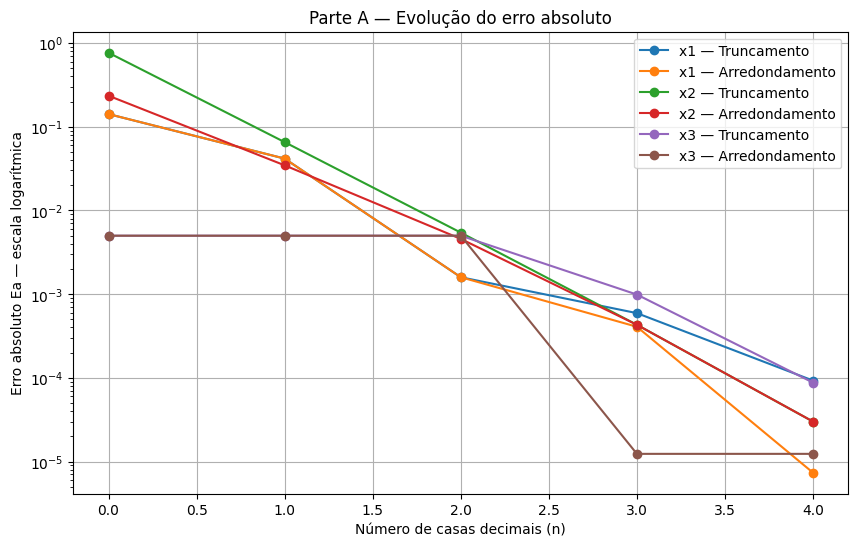

In [ ]:

fig, ax = plt.subplots(figsize=(10, 6))

for nome in valores_A:
    for metodo in ["Truncamento", "Arredondamento"]:
        dados = tabela_A[
            (tabela_A["Valor"] == nome) &
            (tabela_A["Método"] == metodo)
        ]
        ax.semilogy(
            dados["n"],
            dados["Erro absoluto"],
            marker="o",
            label=f"{nome} — {metodo}"
        )

ax.set_xlabel("Número de casas decimais (n)")
ax.set_ylabel("Erro absoluto Ea — escala logarítmica")
ax.set_title("Parte A — Evolução do erro absoluto")
ax.grid(True)
ax.legend()
plt.show()



### Resposta da Parte A

Para os valores e precisões desta atividade, o arredondamento gera erro menor ou igual ao truncamento. Em alguns casos os dois produzem a mesma aproximação.

Exemplos:

- \(x_1=3,14159265\), com \(n=3\):
  - truncamento: \(3,141\), \(E_a=0,00059265\);
  - arredondamento: \(3,142\), \(E_a=0,00040735\).

- \(x_2=98,76543\), com \(n=0\):
  - truncamento: \(98\), \(E_a=0,76543\);
  - arredondamento: \(99\), \(E_a=0,23457\).

Isso porque o arredondamento escolhe o valor mais próximo na precisão adotada, enquanto o truncamento apenas elimina os algarismos posteriores.



# Parte B — Medidas de pressão arterial


In [ ]:

pressao_original = np.array([
    121.7, 120.4, 122.1, 119.8, 121.2,
    120.9, 122.4, 121.0, 120.2, 121.5
])

pressao_arred = arredondar_inteiro_positivo(pressao_original)
pressao_trunc = np.trunc(pressao_original).astype(int)

series_B = {
    "Original": pressao_original,
    "Arredondada": pressao_arred,
    "Truncada": pressao_trunc
}

media_ref = np.mean(pressao_original)

def estatisticas(amostra):
    return {
        "Média (mmHg)": np.mean(amostra),
        "Mínimo (mmHg)": np.min(amostra),
        "Máximo (mmHg)": np.max(amostra),
        "Amplitude (mmHg)": np.max(amostra) - np.min(amostra),
        "Desvio-padrão amostral (mmHg)": np.std(amostra, ddof=1)
    }

tabela_estat_B = pd.DataFrame({
    nome: estatisticas(dados)
    for nome, dados in series_B.items()
}).T

display(tabela_estat_B)
print(f"Média de referência = {media_ref:.4f} mmHg")


,Média (mmHg),Mínimo (mmHg),Máximo (mmHg),Amplitude (mmHg),Desvio-padrão amostral (mmHg)
Original,121.12,119.8,122.4,2.6,0.8337332374
Arredondada,121.10,120.0,122.0,2.0,0.8755950358
Truncada,120.70,119.0,122.0,3.0,0.9486832981


Média de referência = 121.1200 mmHg


In [ ]:

linhas_erros_B = []

for nome, dados in series_B.items():
    media = np.mean(dados)
    ea, er, ep = erros(media_ref, media)
    linhas_erros_B.append({
        "Série": nome,
        "Média (mmHg)": media,
        "Erro absoluto da média (mmHg)": ea,
        "Erro relativo da média": er,
        "Erro percentual da média (%)": ep
    })

tabela_erros_B = pd.DataFrame(linhas_erros_B)
display(tabela_erros_B)


,Série,Média (mmHg),Erro absoluto da média (mmHg),Erro relativo da média,Erro percentual da média (%)
0,Original,121.12,0.00,0.0000000000,0.0000000000
1,Arredondada,121.10,0.02,0.0001651255,0.0165125495
2,Truncada,120.70,0.42,0.0034676354,0.3467635403


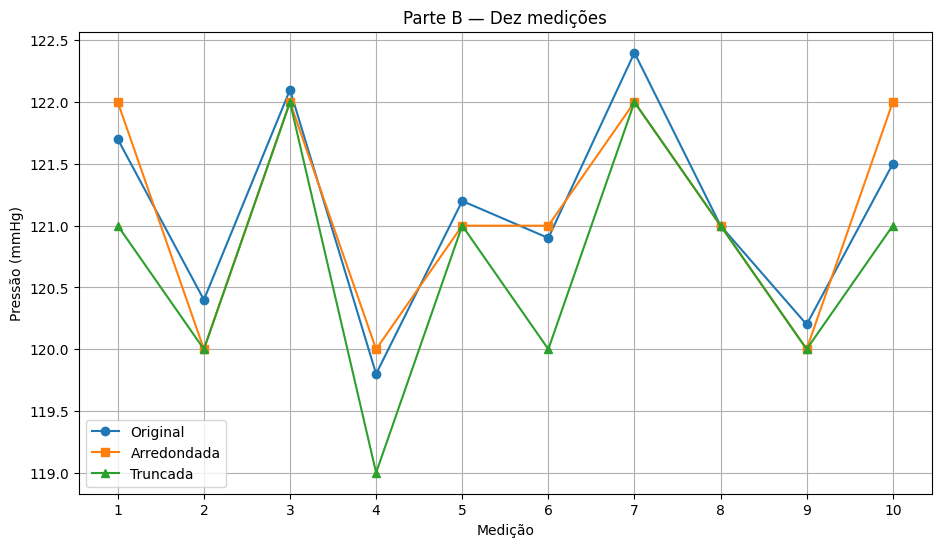

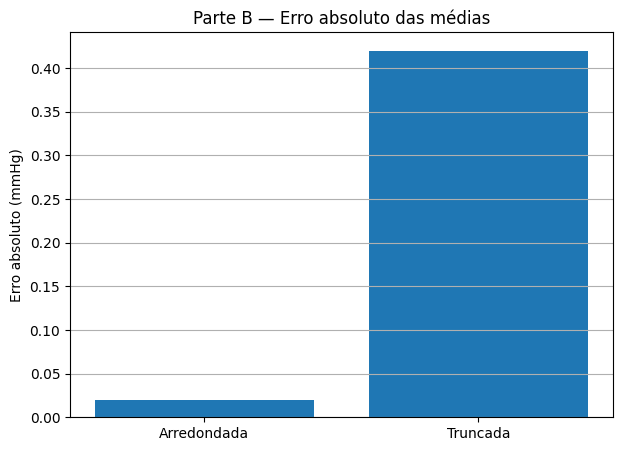

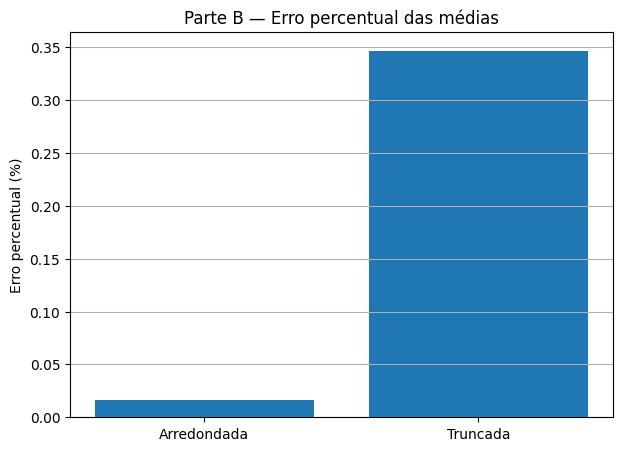

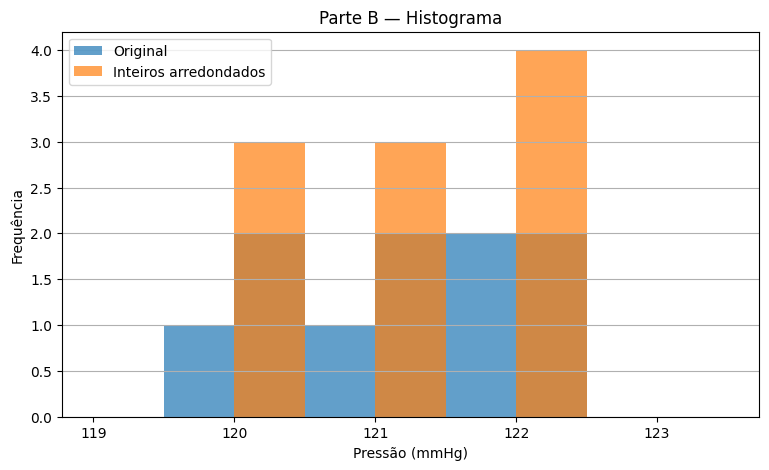

In [ ]:


medicao = np.arange(1, len(pressao_original) + 1)

plt.figure(figsize=(11, 6))
plt.plot(medicao, pressao_original, marker="o", label="Original")
plt.plot(medicao, pressao_arred, marker="s", label="Arredondada")
plt.plot(medicao, pressao_trunc, marker="^", label="Truncada")
plt.xlabel("Medição")
plt.ylabel("Pressão (mmHg)")
plt.title("Parte B — Dez medições")
plt.xticks(medicao)
plt.grid(True)
plt.legend()
plt.show()

dados_aprox_B = tabela_erros_B[tabela_erros_B["Série"] != "Original"]

plt.figure(figsize=(7, 5))
plt.bar(
    dados_aprox_B["Série"],
    dados_aprox_B["Erro absoluto da média (mmHg)"]
)
plt.ylabel("Erro absoluto (mmHg)")
plt.title("Parte B — Erro absoluto das médias")
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(7, 5))
plt.bar(
    dados_aprox_B["Série"],
    dados_aprox_B["Erro percentual da média (%)"]
)
plt.ylabel("Erro percentual (%)")
plt.title("Parte B — Erro percentual das médias")
plt.grid(axis="y")
plt.show()

bins = np.arange(119, 124, 0.5)

plt.figure(figsize=(9, 5))
plt.hist(pressao_original, bins=bins, alpha=0.7, label="Original")
plt.hist(pressao_arred, bins=bins, alpha=0.7, label="Inteiros arredondados")
plt.xlabel("Pressão (mmHg)")
plt.ylabel("Frequência")
plt.title("Parte B — Histograma")
plt.legend()
plt.grid(axis="y")
plt.show()



### Resposta da Parte B

A média original é **121,12 mmHg**. Após arredondamento para inteiros, ela passa para **121,10 mmHg**, com erro absoluto de **0,02 mmHg** e erro percentual de aproximadamente **0,0165%**. Após truncamento, a média é **120,70 mmHg**, com erro absoluto de **0,42 mmHg** e erro percentual de aproximadamente **0,3468%**.

Assim, nesta pequena amostra, o arredondamento inteiro preserva muito bem a média, mas não preserva exatamente a variabilidade. O truncamento provoca uma alteração maior tanto na média quanto na dispersão.



# Parte C — Vazão em um tubo de pequeno diâmetro



In [ ]:

r_mm = 0.80
r = r_mm * 1e-3
L = 0.20
mu = 3.5e-3
dp = 1200.0

Q_ref_C = vazao(r, L, mu, dp)

print(f"Q de referência = {Q_ref_C:.12e} m³/s")
print(f"Q de referência = {Q_ref_C*1e6:.12e} mL/s")


Q de referência = 2.757420751951e-07 m³/s
Q de referência = 2.757420751951e-01 mL/s


In [ ]:

r_arred_mm = round(r_mm, 1)
r_trunc_mm = truncar(r_mm, 1)

mu_arred = round(mu, 3)
mu_trunc = truncar(mu, 3)

dp_arred = round(dp / 100) * 100
dp_trunc = math.trunc(dp / 100) * 100

cenarios_C = {
    "Referência": (r_mm, mu, dp),
    "r arred. 1 casa (mm)": (r_arred_mm, mu, dp),
    "r trunc. 1 casa (mm)": (r_trunc_mm, mu, dp),
    "mu arred. 3 casas": (r_mm, mu_arred, dp),
    "mu trunc. 3 casas": (r_mm, mu_trunc, dp),
    "dp arred. centenas": (r_mm, mu, dp_arred),
    "dp trunc. centenas": (r_mm, mu, dp_trunc),
    "Todas arredondadas": (r_arred_mm, mu_arred, dp_arred),
    "Todas truncadas": (r_trunc_mm, mu_trunc, dp_trunc)
}

linhas_C = []

for nome, (rmm_c, mu_c, dp_c) in cenarios_C.items():
    q = vazao(rmm_c * 1e-3, L, mu_c, dp_c)
    ea, er, ep = erros(Q_ref_C, q)
    linhas_C.append({
        "Cenário": nome,
        "r (mm)": rmm_c,
        "mu (Pa·s)": mu_c,
        "Δp (Pa)": dp_c,
        "Q (m³/s)": q,
        "Erro absoluto (m³/s)": ea,
        "Erro relativo": er,
        "Erro percentual (%)": ep
    })

tabela_C1 = pd.DataFrame(linhas_C)
display(tabela_C1)


,Cenário,r (mm),mu (Pa·s),Δp (Pa),Q (m³/s),Erro absoluto (m³/s),Erro relativo,Erro percentual (%)
0,Referência,0.8,0.0035,1200.0,0.0000002757,0.0000000000,0.0000000000,0.0000000000
1,r arred. 1 casa (mm),0.8,0.0035,1200.0,0.0000002757,0.0000000000,0.0000000000,0.0000000000
2,r trunc. 1 casa (mm),0.8,0.0035,1200.0,0.0000002757,0.0000000000,0.0000000000,0.0000000000
3,mu arred. 3 casas,0.8,0.0040,1200.0,0.0000002413,0.0000000345,0.1250000000,12.5000000000
4,mu trunc. 3 casas,0.8,0.0030,1200.0,0.0000003217,0.0000000460,0.1666666667,16.6666666667
5,dp arred. centenas,0.8,0.0035,1200.0,0.0000002757,0.0000000000,0.0000000000,0.0000000000
6,dp trunc. centenas,0.8,0.0035,1200.0,0.0000002757,0.0000000000,0.0000000000,0.0000000000
7,Todas arredondadas,0.8,0.0040,1200.0,0.0000002413,0.0000000345,0.1250000000,12.5000000000
8,Todas truncadas,0.8,0.0030,1200.0,0.0000003217,0.0000000460,0.1666666667,16.6666666667



### Resposta da parte C.1

O raio \(0,80\) mm não muda quando arredondado ou truncado para uma casa decimal. Da mesma forma, \(1200\) Pa já é múltiplo de 100 Pa e permanece igual quando aproximado para centenas.

A viscosidade é o parâmetro que muda:

- arredondamento: \(0,0035\to0,004\) Pa·s;
- truncamento: \(0,0035\to0,003\) Pa·s.

A vazão de referência é aproximadamente

\[
Q=2,757420751951\times10^{-7}\ \text{m}^3/\text{s}.
\]

Como \(Q\propto1/\mu\), o arredondamento de \(\mu\) produz erro de aproximadamente **12,5%** em \(Q\), enquanto o truncamento produz aproximadamente **16,67%**.



## C.2 — Sensibilidade ao raio

Para visualizar a sensibilidade, são utilizados 201 valores igualmente espaçados entre 0,70 e 0,90 mm.


In [ ]:

raios_mm = np.linspace(0.70, 0.90, 201)

Q_ref_sens = np.array([
    vazao(rr * 1e-3, L, mu, dp)
    for rr in raios_mm
])

raios_arred_mm = np.array([
    round(float(rr), 1)
    for rr in raios_mm
])

raios_trunc_mm = np.array([
    truncar(float(rr), 1)
    for rr in raios_mm
])

Q_arred_sens = np.array([
    vazao(rr * 1e-3, L, mu, dp)
    for rr in raios_arred_mm
])

Q_trunc_sens = np.array([
    vazao(rr * 1e-3, L, mu, dp)
    for rr in raios_trunc_mm
])

Ea_arred = np.abs(Q_ref_sens - Q_arred_sens)
Ea_trunc = np.abs(Q_ref_sens - Q_trunc_sens)

Er_arred = Ea_arred / np.abs(Q_ref_sens)
Er_trunc = Ea_trunc / np.abs(Q_ref_sens)

Ep_arred = 100 * Er_arred
Ep_trunc = 100 * Er_trunc

plt.figure(figsize=(10, 6))
plt.plot(raios_mm, Q_ref_sens, label="Q referência")
plt.plot(raios_mm, Q_arred_sens, label="Q com r arredondado")
plt.plot(raios_mm, Q_trunc_sens, label="Q com r truncado")
plt.xlabel("Raio (mm)")
plt.ylabel("Q (m³/s)")
plt.title("Parte C — Vazão em função do raio")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(raios_mm, Ea_arred, label="Arredondamento")
plt.plot(raios_mm, Ea_trunc, label="Truncamento")
plt.xlabel("Raio de referência (mm)")
plt.ylabel("Erro absoluto de Q (m³/s)")
plt.title("Parte C — Erro absoluto de Q")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(raios_mm, Er_arred, label="Arredondamento")
plt.plot(raios_mm, Er_trunc, label="Truncamento")
plt.xlabel("Raio de referência (mm)")
plt.ylabel("Erro relativo de Q")
plt.title("Parte C — Erro relativo de Q")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(raios_mm, Ep_arred, label="Arredondamento")
plt.plot(raios_mm, Ep_trunc, label="Truncamento")
plt.xlabel("Raio de referência (mm)")
plt.ylabel("Erro percentual de Q (%)")
plt.title("Parte C — Erro percentual de Q")
plt.grid(True)
plt.legend()
plt.show()



### Explicação de C.2

Como

\[
Q\propto r^4,
\]

uma pequena variação do raio é amplificada na vazão. Se \(r\) passa para \(r(1+\varepsilon)\),

\[
\frac{Q_{\text{novo}}}{Q}=(1+\varepsilon)^4
=1+4\varepsilon+6\varepsilon^2+4\varepsilon^3+\varepsilon^4.
\]

Para \(|\varepsilon|\ll1\),

\[
\frac{\Delta Q}{Q}\approx4\frac{\Delta r}{r}.
\]

Logo, para perturbações pequenas, um erro relativo de cerca de 1% no raio pode produzir aproximadamente 4% de erro relativo na vazão.



# Parte D — Escoamento em um nanocateter



In [ ]:

r0_nm = 50.0
r0 = r0_nm * 1e-9
L_D = 10e-6
mu_D = 3.5e-3
dp_D = 5000.0

Q0_D = vazao(r0, L_D, mu_D, dp_D)

print(f"Q(50 nm) = {Q0_D:.15e} m³/s")


Q(50 nm) = 3.506241800881466e-19 m³/s


## D.1 — Erro geométrico

In [ ]:

delta_r_nm = np.arange(0.1, 5.0 + 0.05, 0.1)

r_menos_nm = r0_nm - delta_r_nm
r_mais_nm = r0_nm + delta_r_nm

Q_menos = np.array([
    vazao(rr * 1e-9, L_D, mu_D, dp_D)
    for rr in r_menos_nm
])

Q_mais = np.array([
    vazao(rr * 1e-9, L_D, mu_D, dp_D)
    for rr in r_mais_nm
])

erro_abs_max_D = np.maximum(
    np.abs(Q_menos - Q0_D),
    np.abs(Q_mais - Q0_D)
)

erro_rel_max_D = erro_abs_max_D / abs(Q0_D)
erro_pct_max_D = 100 * erro_rel_max_D

aprox_linear_rel = 4 * (delta_r_nm / r0_nm)
aprox_linear_pct = 100 * aprox_linear_rel

tabela_D1 = pd.DataFrame({
    "Δr (nm)": delta_r_nm,
    "r- (nm)": r_menos_nm,
    "r+ (nm)": r_mais_nm,
    "Q(r-) (m³/s)": Q_menos,
    "Q(r) (m³/s)": Q0_D,
    "Q(r+) (m³/s)": Q_mais,
    "Erro abs. máximo (m³/s)": erro_abs_max_D,
    "Erro rel. máximo": erro_rel_max_D,
    "Erro percentual máximo (%)": erro_pct_max_D,
    "Aprox. linear (%)": aprox_linear_pct
})

display(tabela_D1)
